# Project 03 — Credit Risk: PD / LGD / EAD & Expected Loss
## Notebook 02 — Probability of Default Model

This notebook builds a baseline borrower-level Probability of Default (PD) model using logistic regression. The aim is to create a model that is interpretable enough to explain, then assess two separate questions:

1. **Discrimination:** Does the model rank loans that default above loans that do not?
2. **Calibration:** Do the predicted probabilities line up with observed default rates?

The prepared development and validation datasets from Notebook 01 are reused here. Data preparation is not repeated unless a check is needed for modeling.

## 1. PD Modeling Framework

Probability of Default (PD) is the probability that a loan defaults over the outcome horizon represented by the target variable, conditional on the information used by the model.

In this notebook, `default_flag` is the target:

- `0` — Fully Paid
- `1` — Charged Off

Logistic regression is a useful baseline because it estimates probabilities directly and its coefficients can be interpreted through changes in log-odds.

The linear predictor is:

$$
z_i = \beta_0 + \beta_1 X_{i1} + \cdots + \beta_p X_{ip}
$$

The logistic function maps this value to a probability between zero and one:

$$
PD_i = P(Default_i=1 \mid X_i)
= \frac{1}{1 + e^{-z_i}}
$$

The sign of a coefficient indicates the direction of its association with default odds, holding the other model features constant. Coefficients describe associations, not necessarily causal effects.

The model is a baseline rather than a production credit score. Its results depend on the selected features, the historical sample, and the definition of default used in Notebook 01.

### 1.1 Load Development and Validation Data

The development sample is used to fit the model. The later validation sample is held back for evaluation. Keeping the split chronological is important because a random split can make a model look stronger than it may be on loans originated in a later period.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

In [15]:
data_dir = Path("../data/processed")

development_path = data_dir / "credit_risk_development.csv"
validation_path = data_dir / "credit_risk_validation.csv"

train_df = pd.read_csv(development_path)
valid_df = pd.read_csv(validation_path)

print(f"Development sample: {len(train_df):.0f} loans")
print(f"Validation sample: {len(valid_df):.0f} loans")

train_df.head()

Development sample: 1495018 loans
Validation sample: 368062 loans


,id,loan_amnt,funded_amnt,int_rate,grade,emp_length,home_ownership,annual_inc,issue_d,loan_status,purpose,dti,fico_range_low,fico_range_high,recoveries,default_flag,fico_avg,loan_to_income
0,85781,1400.0,1400.0,10.91,C,< 1 year,RENT,40000.0,2007-06-01,Does not meet the credit policy. Status:Fully ...,other,8.61,670.0,674.0,0.0,0,672.0,0.035000
1,87023,7500.0,7500.0,13.75,E,< 1 year,OWN,22000.0,2007-06-01,Fully Paid,debt_consolidation,14.29,660.0,664.0,0.0,0,662.0,0.340909
2,88637,6000.0,6000.0,10.59,C,< 1 year,RENT,20000.0,2007-06-01,Does not meet the credit policy. Status:Fully ...,debt_consolidation,12.90,695.0,699.0,0.0,0,697.0,0.300000
3,88046,4400.0,4400.0,9.64,B,2 years,MORTGAGE,30000.0,2007-06-01,Does not meet the credit policy. Status:Fully ...,debt_consolidation,3.72,695.0,699.0,0.0,0,697.0,0.146667
4,85961,1200.0,1200.0,9.01,B,< 1 year,RENT,36000.0,2007-06-01,Does not meet the credit policy. Status:Fully ...,other,3.27,705.0,709.0,0.0,0,707.0,0.033333


## 2. Feature Selection

Feature selection is guided by three principles:

1. **Predictive relevance:** Features should capture borrower creditworthiness, financial capacity, or loan characteristics associated with default risk.
2. **Point-in-time availability:** Features must be available when the loan application is assessed or the loan is originated.
3. **Leakage prevention:** Features containing information generated after loan origination or reflecting the loan outcome must not be used as predictors.

The following table documents the treatment of every column in the prepared dataset.

| Feature | Description | Selected | Rationale |
|---|---|---|---|
| `id` | Loan identifier | No | Unique identifier with no meaningful borrower risk information. |
| `loan_amnt` | Loan amount requested | Yes | Measures the amount of credit requested by the borrower. |
| `funded_amnt` | Amount funded by the lender | No | Closely related to `loan_amnt`; excluded to reduce redundancy in the baseline model. |
| `int_rate` | Loan interest rate | Yes | Reflects the price of credit and may capture risk information incorporated into loan pricing. |
| `grade` | Lender-assigned credit grade | Yes | Summarizes the lender's assessment of borrower credit risk. |
| `emp_length` | Employment length | Yes | Provides a proxy for employment stability. |
| `home_ownership` | Housing status | Yes | Provides contextual information about the borrower's housing situation. |
| `annual_inc` | Reported annual income | Yes | Measures the borrower's reported income and repayment capacity. |
| `issue_d` | Loan issuance date | No | Used for chronological splitting and temporal analysis rather than as a direct baseline predictor. |
| `loan_status` | Loan repayment status | No | Contains outcome-related information and may directly reveal whether a loan defaulted. |
| `purpose` | Stated loan purpose | Yes | Captures the intended use of borrowed funds. |
| `dti` | Debt-to-income ratio | Yes | Measures existing debt obligations relative to income. |
| `fico_range_low` | Lower bound of FICO score range | No | Excluded because `fico_avg` is used to represent the same underlying credit-score information. |
| `fico_range_high` | Upper bound of FICO score range | No | Excluded because `fico_avg` is used to represent the same underlying credit-score information. |
| `recoveries` | Amount recovered after charge-off | No | Post-default information that creates direct target leakage. |
| `default_flag` | Binary default indicator | Target | The outcome to be predicted, not an input feature. |
| `fico_avg` | Average of the FICO score range | Yes | Provides a continuous measure of borrower credit quality. |
| `loan_to_income` | Loan amount relative to annual income | Yes | Captures loan size relative to borrower income, subject to verifying that it was constructed from origination-time information. |

The baseline model therefore uses nine predictors: `loan_amnt`, `int_rate`, `grade`, `emp_length`, `home_ownership`, `annual_inc`, `purpose`, `dti`, `fico_avg`, and `loan_to_income`.

The FICO range boundaries are excluded because their information is represented by `fico_avg`. Similarly, `funded_amnt` is excluded from the baseline because it is closely related to `loan_amnt`.

The variables `recoveries`, `loan_status`, and `default_flag` are excluded from the predictor set because they contain outcome-related or post-origination information. The issuance date is retained for temporal splitting and validation.

Feature availability must be interpreted carefully: the dataset alone does not establish when every field was recorded. Before treating a feature as suitable for an application-time model, its availability at the intended prediction point should be verified.

In [16]:
target = "default_flag"

numeric_features = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "fico_avg",
    "loan_to_income",
]

categorical_features = [
    "grade",
    "emp_length",
    "home_ownership",
    "purpose",
]

features = numeric_features + categorical_features

missing_train = sorted(set(features + [target]) - set(train_df.columns))
missing_valid = sorted(set(features + [target]) - set(valid_df.columns))

print("Selected predictors:", features)
print("Number of predictors:", len(features))
print("Missing from development data:", missing_train)
print("Missing from validation data:", missing_valid)

Selected predictors: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_avg', 'loan_to_income', 'grade', 'emp_length', 'home_ownership', 'purpose']
Number of predictors: 10
Missing from development data: []
Missing from validation data: []


## 3. Logistic Regression

The preprocessing and model fitting steps are combined in a single scikit-learn pipeline. This keeps the transformations consistent and ensures that imputation, scaling, and category encoding are learned from the development sample only.

The model uses L2 regularization with `C=1.0` as a baseline setting. Hyperparameter tuning is intentionally left out of this first version so that the focus stays on the end-to-end PD workflow.

In [17]:
X_train = train_df[features].copy()
y_train = train_df[target].astype(int).copy()

X_valid = valid_df[features].copy()
y_valid = valid_df[target].astype(int).copy()

target_summary = pd.DataFrame({
    "Loans": [len(y_train), len(y_valid)],
    "Observed default rate": [y_train.mean(), y_valid.mean()],
}, index=["Development", "Validation"])

display(target_summary.style.format({
    "Loans": "{:,.0f}",
    "Observed default rate": "{:.2%}",
}))

,Loans,Observed default rate
Development,"1,495,018",18.77%
Validation,"368,062",22.47%


### 3.1 Preprocessing

Numerical features are imputed with their development-sample median and standardized. Categorical features are imputed with their most frequent category and one-hot encoded.

The encoder drops the first category in each categorical feature. This provides an explicit reference category for coefficient interpretation. Previously unseen categories in validation data are handled without stopping the pipeline.

In [18]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

### 3.2 Fit the Baseline Model

The logistic regression model is fitted on the development sample. The validation sample remains untouched until predictions are generated for evaluation.

In [19]:
pd_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "logistic_regression",
            LogisticRegression(
                C=1.0,
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

pd_model.fit(X_train, y_train)

fitted_logistic = pd_model.named_steps["logistic_regression"]
print(f"Model fitted. Iterations used: {fitted_logistic.n_iter_[0]}")
print(f"Converged within max_iter=1000: {fitted_logistic.n_iter_[0] < 1000}")

Model fitted. Iterations used: 34
Converged within max_iter=1000: True


### 3.3 Predicted Probability of Default

The model's probability for class `1` is treated as the predicted PD. We keep the predictions alongside the original records so that the risk-band and calibration analyses use the same validation observations.

In [20]:
y_train_pd = pd_model.predict_proba(X_train)[:, 1]
y_valid_pd = pd_model.predict_proba(X_valid)[:, 1]

train_predictions = train_df.copy()
valid_predictions = valid_df.copy()

train_predictions["predicted_pd"] = y_train_pd
valid_predictions["predicted_pd"] = y_valid_pd

pd_summary = pd.DataFrame({
    "Development": pd.Series(y_train_pd).describe(
        percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
    ),
    "Validation": pd.Series(y_valid_pd).describe(
        percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
    ),
}).T

display(pd_summary.style.format("{:.4f}"))

,count,mean,std,min,5%,25%,50%,75%,95%,max
Development,1495018.0000,0.1877,0.1073,0.0000,0.0475,0.1061,0.1716,0.2514,0.3920,1.0000
Validation,368062.0000,0.1826,0.1205,0.0000,0.0424,0.0851,0.1577,0.2531,0.4109,1.0000


### 3.4 Coefficients and Odds Ratios

For a fitted logistic regression, exponentiating a coefficient gives an odds ratio:

$$
OR_j = e^{\\beta_j}
$$

For standardized numerical features, the odds ratio represents the change in odds associated with a one-standard-deviation increase in that feature, holding other features constant. For one-hot-encoded categorical features, it compares that category with the dropped reference category.

An odds ratio above one indicates higher estimated odds of default relative to the relevant comparison; below one indicates lower estimated odds. These are conditional associations, not causal effects. Because the model is regularized, coefficients are best treated as descriptive model effects rather than as inferential estimates with p-values.

In [21]:
fitted_preprocessor = pd_model.named_steps["preprocessor"]
fitted_logistic = pd_model.named_steps["logistic_regression"]

feature_names = fitted_preprocessor.get_feature_names_out()

model_summary = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": fitted_logistic.coef_[0],
})
model_summary["Odds Ratio"] = np.exp(model_summary["Coefficient"])
model_summary["Absolute Coefficient"] = model_summary["Coefficient"].abs()

model_summary = (
    model_summary
    .sort_values("Absolute Coefficient", ascending=False)
    .drop(columns="Absolute Coefficient")
    .reset_index(drop=True)
)

print(f"Development observations: {len(X_train):,}")
print(f"Encoded model features: {len(feature_names)}")
print(f"Intercept: {fitted_logistic.intercept_[0]:.4f}")

display(model_summary.style.format({
    "Coefficient": "{:.4f}",
    "Odds Ratio": "{:.4f}",
}))

Development observations: 1,495,018
Encoded model features: 45
Intercept: -0.9018


,Feature,Coefficient,Odds Ratio
0,categorical__grade_A,-0.9382,0.3913
1,categorical__grade_B,-0.4433,0.6419
2,categorical__home_ownership_MORTGAGE,-0.4228,0.6552
3,numeric__int_rate,0.2809,1.3244
4,categorical__home_ownership_OWN,-0.2764,0.7585
5,categorical__emp_length_Unknown,0.2715,1.3120
6,categorical__purpose_wedding,-0.2561,0.7741
7,categorical__purpose_small_business,0.2253,1.2527
8,categorical__purpose_car,-0.2107,0.8100
9,categorical__purpose_house,-0.2049,0.8148


## 4. Risk Band Analysis

To make the model easier to interpret, validation loans are grouped into five PD bands. The cutoffs below are simple analytical thresholds for this project, not approved lending-policy boundaries.

For each band, we compare the average predicted PD with the observed default rate. Increasing observed default rates across the bands would indicate that the model ranks loans by risk in a useful way.

In [22]:
pd_bins = [0.0, 0.05, 0.10, 0.20, 0.35, 1.0]
risk_labels = ["Very Low", "Low", "Medium", "High", "Very High"]

valid_predictions["risk_band"] = pd.cut(
    valid_predictions["predicted_pd"],
    bins=pd_bins,
    labels=risk_labels,
    include_lowest=True,
    right=True,
)

risk_band_summary = (
    valid_predictions
    .groupby("risk_band", observed=False)
    .agg(
        loan_count=("default_flag", "size"),
        average_predicted_pd=("predicted_pd", "mean"),
        actual_default_rate=("default_flag", "mean"),
    )
    .reset_index()
)

display(risk_band_summary.style.format({
    "loan_count": "{:,.0f}",
    "average_predicted_pd": "{:.2%}",
    "actual_default_rate": "{:.2%}",
}))

,risk_band,loan_count,average_predicted_pd,actual_default_rate
0,Very Low,"34,965",4.07%,4.89%
1,Low,"75,302",7.17%,10.82%
2,Medium,"115,694",14.59%,19.77%
3,High,"106,582",26.26%,31.87%
4,Very High,"35,519",43.75%,45.03%


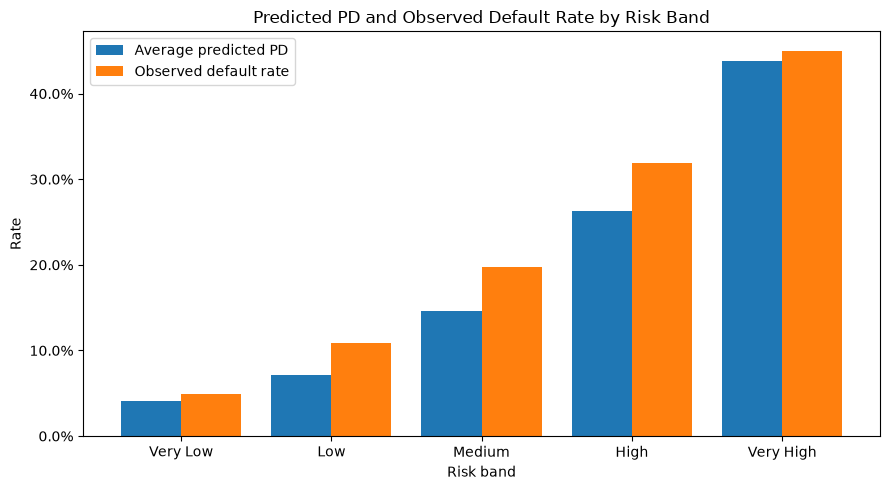

In [23]:
ax = risk_band_summary.set_index("risk_band")[
    ["average_predicted_pd", "actual_default_rate"]
].plot(kind="bar", figsize=(9, 5), width=0.8)

ax.set_title("Predicted PD and Observed Default Rate by Risk Band")
ax.set_xlabel("Risk band")
ax.set_ylabel("Rate")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(["Average predicted PD", "Observed default rate"])
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 4.1 Interpretation

Use the table and chart above to check two things: whether observed default rates rise from Very Low to Very High risk, and whether predicted PD is close to the observed rate within each band.

A consistent increase in observed default rates supports the model's ranking ability. Differences between predicted PD and observed default rate indicate calibration error; they should not be interpreted as a failure of ranking by themselves. The size and direction of those gaps are quantified in Section 6.

## 5. Model Performance

The predictive performance of the Probability of Default (PD) model is evaluated using three measures:

- **ROC-AUC:** Measures the model's ability to rank defaulting loans above non-defaulting loans across classification thresholds.
- **Kolmogorov–Smirnov (KS) Statistic:** Measures the maximum separation between the cumulative distributions of predicted PD for defaulting and non-defaulting loans.
- **Gini Coefficient:** Provides a rescaled measure of discrimination derived from ROC-AUC.

The metrics are calculated on the validation sample to evaluate performance on data not used to fit the model.

The Gini coefficient is calculated as:

$$
Gini = 2 \times AUC - 1
$$

Higher ROC-AUC, KS, and Gini values generally indicate stronger discrimination. These measures evaluate risk ranking rather than the accuracy of predicted probability levels; PD calibration is assessed separately.

In [24]:
y_true = y_valid
y_score = y_valid_pd

roc_auc = roc_auc_score(y_true, y_score)
gini = 2 * roc_auc - 1

fpr, tpr, thresholds = roc_curve(y_true, y_score)
ks_values = tpr - fpr
ks_index = np.argmax(ks_values)
ks_statistic = ks_values[ks_index]

performance_summary = pd.DataFrame({
    "Metric": ["ROC-AUC", "KS statistic", "Gini coefficient"],
    "Value": [roc_auc, ks_statistic, gini],
})

display(performance_summary.style.format({"Value": "{:.4f}"}))

,Metric,Value
0,ROC-AUC,0.6969
1,KS statistic,0.2874
2,Gini coefficient,0.3937


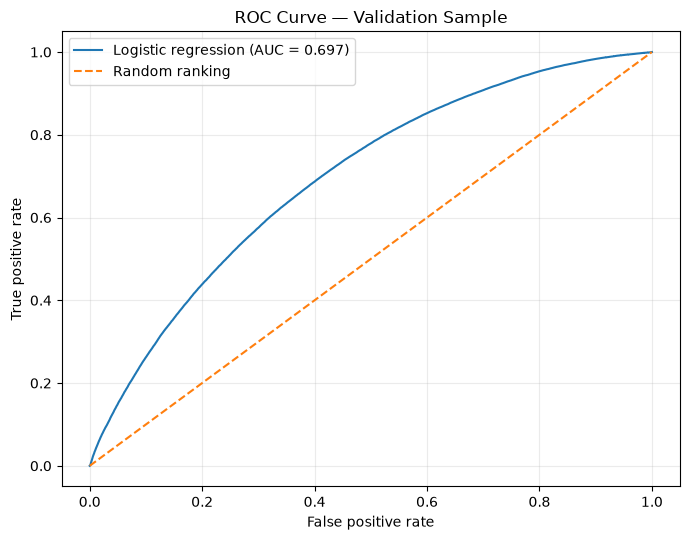

In [25]:
plt.figure(figsize=(7, 5.5))
plt.plot(fpr, tpr, label=f"Logistic regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random ranking")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curve — Validation Sample")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 5.1 Interpretation

Read the metrics together rather than treating any one of them as a pass/fail result. AUC summarizes ranking performance across thresholds, KS shows the largest separation between the score distributions, and Gini expresses discrimination on a related scale.

The results are useful for comparing this baseline with later models built on the same target and validation period. They do not, by themselves, show that the predicted PD values are calibrated or that the model is suitable for production use.

## 6. PD Calibration

PD calibration assesses whether the probabilities estimated by the model are consistent with observed default frequencies.

A model may rank borrowers effectively while systematically overestimating or underestimating their probabilities of default.

This section evaluates calibration using the validation sample by comparing:

- **Mean predicted PD:** Average probability of default estimated by the model.
- **Observed default rate:** Actual proportion of loans that defaulted.
- **Calibration gap:** Observed default rate minus mean predicted PD.

The calibration gap is defined as:

$$
Calibration\ Gap = Observed\ Default\ Rate - Mean\ Predicted\ PD
$$

A positive gap indicates that the model underestimates the observed default rate, while a negative gap indicates overestimation.

Calibration is assessed both across the entire validation sample and within individual risk bands.

In [26]:
overall_calibration = pd.DataFrame({
    "Mean predicted PD": [valid_predictions["predicted_pd"].mean()],
    "Observed default rate": [valid_predictions["default_flag"].mean()],
})
overall_calibration["Calibration gap"] = (
    overall_calibration["Observed default rate"]
    - overall_calibration["Mean predicted PD"]
)

display(overall_calibration.style.format("{:.2%}"))

calibration_summary = risk_band_summary.rename(columns={
    "loan_count": "Loan count",
    "average_predicted_pd": "Mean predicted PD",
    "actual_default_rate": "Observed default rate",
}).copy()

calibration_summary["Calibration gap"] = (
    calibration_summary["Observed default rate"]
    - calibration_summary["Mean predicted PD"]
)

display(calibration_summary.style.format({
    "Loan count": "{:,.0f}",
    "Mean predicted PD": "{:.2%}",
    "Observed default rate": "{:.2%}",
    "Calibration gap": "{:+.2%}",
}))

,Mean predicted PD,Observed default rate,Calibration gap
0,18.26%,22.47%,4.21%


,risk_band,Loan count,Mean predicted PD,Observed default rate,Calibration gap
0,Very Low,"34,965",4.07%,4.89%,+0.82%
1,Low,"75,302",7.17%,10.82%,+3.66%
2,Medium,"115,694",14.59%,19.77%,+5.18%
3,High,"106,582",26.26%,31.87%,+5.62%
4,Very High,"35,519",43.75%,45.03%,+1.27%


### 6.1 Interpretation

Compare the overall calibration gap with the gaps by risk band. The overall result shows whether predicted PD is too high or too low on average; the band-level results show whether that pattern is consistent across the risk spectrum.

If observed default rates exceed predicted PD in most or all bands, the baseline is underestimating risk and may need recalibration. Any recalibration should be fitted on a separate calibration subset and then evaluated on an untouched test sample. Reusing the same validation sample for both fitting and evaluation would produce an optimistic assessment.

## 7. Key Findings

This notebook establishes an interpretable logistic-regression baseline for borrower-level PD estimation. The main conclusions should be drawn from the validation results above:

- **Feature design:** Ten origination-related predictors are used. Post-outcome fields such as `recoveries` and `loan_status` are excluded to avoid target leakage.
- **Risk differentiation:** The risk-band table shows whether observed default rates increase with model-estimated risk.
- **Discrimination:** ROC-AUC, KS, and Gini summarize how well the model ranks defaulting loans above non-defaulting loans.
- **Calibration:** The overall and band-level gaps show whether the predicted probabilities align with observed default frequencies.
- **Limitations:** `grade` and `int_rate` incorporate lender underwriting and pricing decisions. Their inclusion is appropriate only if the intended scoring point occurs after those values are available. The model also needs continued scrutiny for temporal stability and outcome-horizon effects.

The model is a baseline, not a production-ready credit decision system. Its PD estimates should not be used for expected-loss calculations without confirming target maturity, feature availability, and calibration. The next project components can use the PD framework as an input while separately estimating Loss Given Default (LGD) and Exposure at Default (EAD).

In [27]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

train_predictions[["id", "predicted_pd"]].to_csv(
    output_dir / "credit_risk_development_pd.csv",
    index=False,
)

valid_predictions[["id", "predicted_pd"]].to_csv(
    output_dir / "credit_risk_validation_pd.csv",
    index=False,
)

print("PD predictions exported successfully.")
print(f"Development predictions: {len(train_predictions):,}")
print(f"Validation predictions: {len(valid_predictions):,}")


PD predictions exported successfully.
Development predictions: 1,495,018
Validation predictions: 368,062
